In [ ]:
import os
import numpy as np
import torch
import yaml

from data import PtychographyDataset
from ptychi_utils import place_patches_fourier_shift

from matplotlib import pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import cmcrameri.cm as cmc

%matplotlib inline
plt.style.use('/home/beams/AILEENLUO/stylesheet.mplstyle')

In [2]:
results_dir = '/scratch/aileenluo/ptycho-vit/results/run106'

gt_diff_test = np.load(os.path.join(results_dir, 'gt_diff_coins.npy'))
gt_amp_test = np.load(os.path.join(results_dir, 'gt_amp_coins.npy'))
gt_ph_test = np.load(os.path.join(results_dir, 'gt_ph_coins.npy'))
pred_diff_test = np.load(os.path.join(results_dir, 'pred_diff_coins.npy'))
pred_amp_test = np.load(os.path.join(results_dir, 'pred_amp_coins.npy'))
pred_ph_test = np.load(os.path.join(results_dir, 'pred_ph_coins.npy'))

gt_diff_test.shape

(1908, 256, 256)

In [3]:
config_path = '/scratch/aileenluo/ptycho-vit/models/run106/config.yaml'

def load_config(path):
    """Load configuration from YAML file."""
    with open(path, 'r') as f:
        config = yaml.safe_load(f)
        return config

config = load_config(config_path)

In [4]:
# Data for object patch placement
#data_file = data_source = '/home/beams/AILEENLUO/ptycho_simulation_factory/outputs/horse256/horse256_dp.hdf5'
data_file = '/home/beams/AILEENLUO/ptycho_simulation_factory/outputs/coins256/coins256_dp.hdf5'
#data_file = '/scratch/aileenluo/ptycho-vit/data/cameraman256_dp.hdf5'
#data_file = '/scratch/aileenluo/ptycho-vit/data/brick256_dp.hdf5'
dataset = PtychographyDataset(
    data_file, 
    config['data']['scale'],
    config['data'].get('normalization_dict_path')
)
tmp = dataset[0] # Just to extract object and position information
positions = dataset._cached_probe_positions

In [8]:
# pred_amp_object = torch.zeros((1048, 1048))
# pred_ph_object = torch.zeros((1048, 1048))
# buffer = torch.zeros((1048, 1048))
pred_amp_object = torch.zeros((606, 768))
pred_ph_object = torch.zeros((606, 768))
buffer = torch.zeros((606, 768))

pred_amp_object = place_patches_fourier_shift(
    pred_amp_object, 
    positions, 
    torch.from_numpy(pred_amp_test[:, 64:-64, 64:-64]), 
    "add", 
    False, 
    pad=32
    )
pred_ph_object = place_patches_fourier_shift(
    pred_ph_object, 
    positions, 
    torch.from_numpy(pred_ph_test[:, 64:-64, 64:-64]), 
    "add", 
    False, 
    pad=32
    )
buffer = place_patches_fourier_shift(
    buffer, 
    positions, 
    torch.ones_like(torch.from_numpy(pred_ph_test[:, 64:-64, 64:-64])), 
    "add", 
    False, 
    pad=32
    )

# gt_ph_object = torch.zeros((1048, 1048))
# gt_amp_object = torch.zeros((1048, 1048))
gt_amp_object = torch.zeros((606, 768))
gt_ph_object = torch.zeros((606, 768))

gt_amp_object = place_patches_fourier_shift(
    gt_amp_object, 
    positions, 
    torch.from_numpy(gt_amp_test[:, 64:-64, 64:-64]), 
    "add", 
    False,
    pad=32
    )
gt_ph_object = place_patches_fourier_shift(
    gt_ph_object, 
    positions, 
    torch.from_numpy(gt_ph_test[:, 64:-64, 64:-64]), 
    "add", 
    False, 
    pad=32
    )


In [9]:
pred_amp_object = pred_amp_object / torch.clip(buffer, min=1)
pred_ph_object = pred_ph_object / torch.clip(buffer, min=1)

gt_amp_object = gt_amp_object / torch.clip(buffer, min=1)
gt_ph_object = gt_ph_object / torch.clip(buffer, min=1)

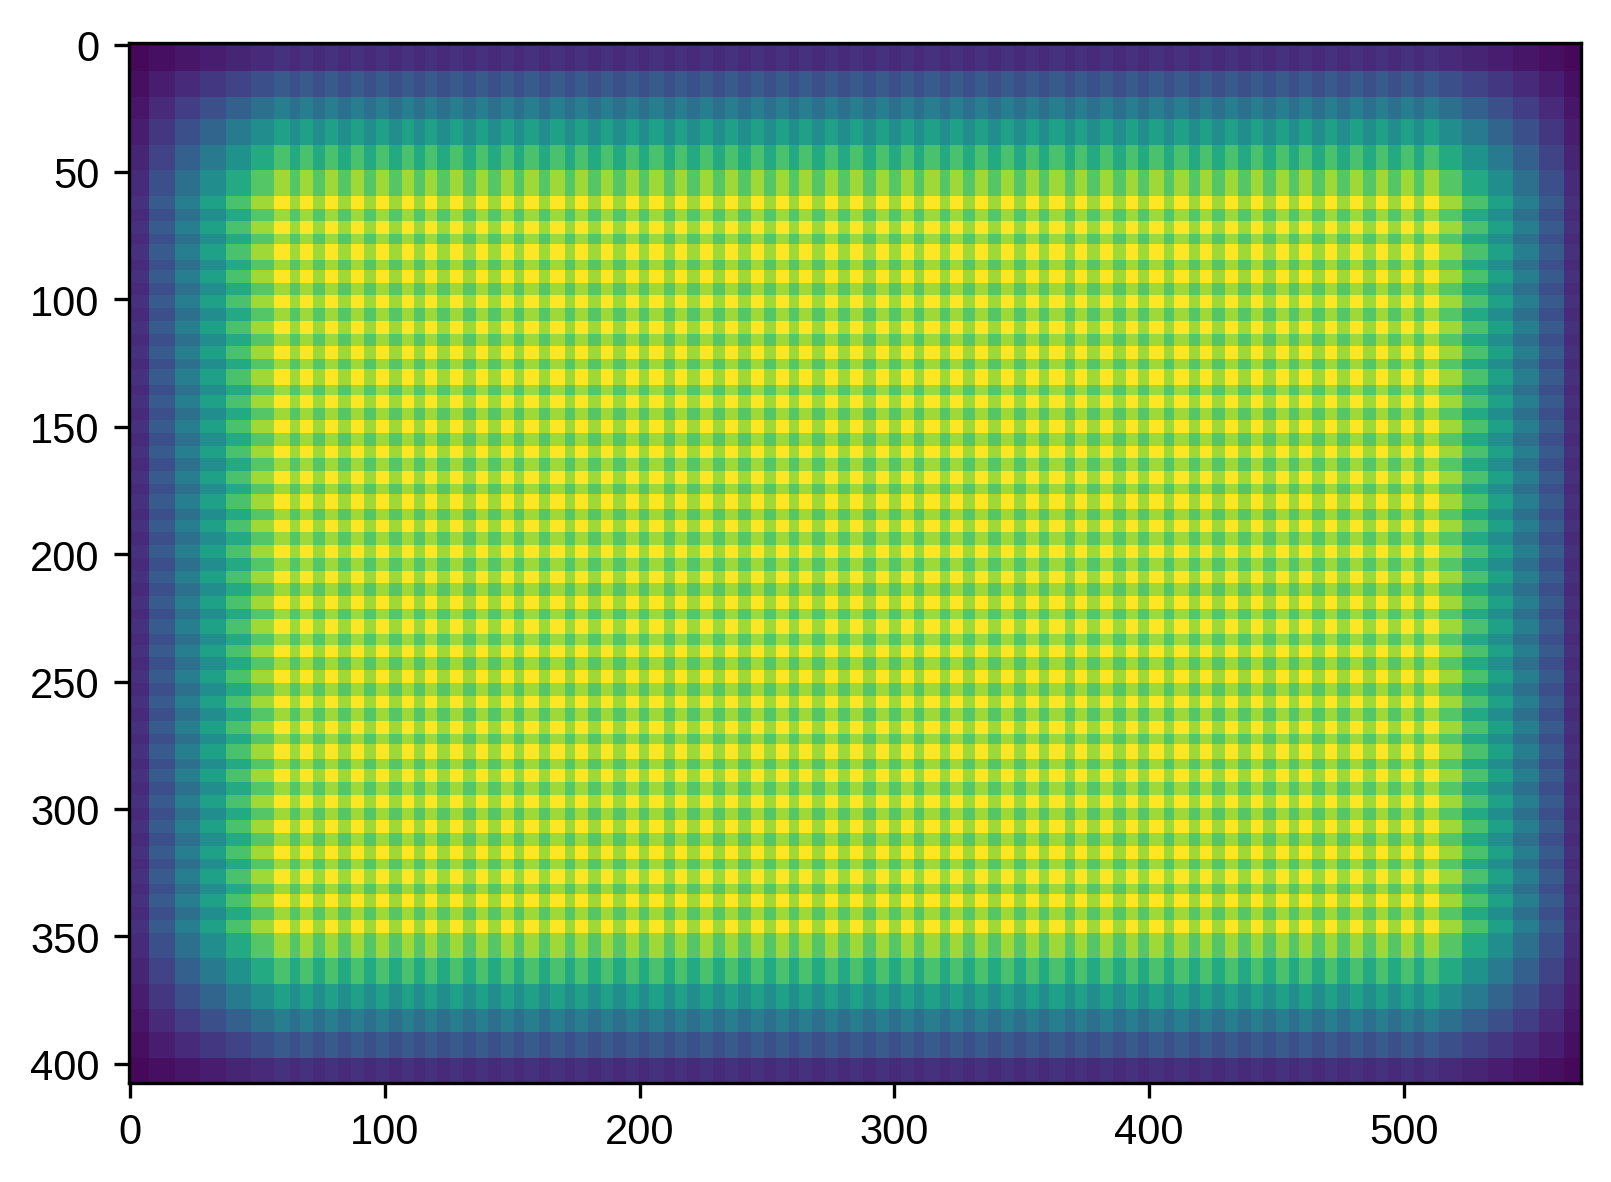

In [10]:
plt.imshow(buffer[99:-99, 99:-99], interpolation='none')

Text(0.5, 1.0, 'Predicted phase')

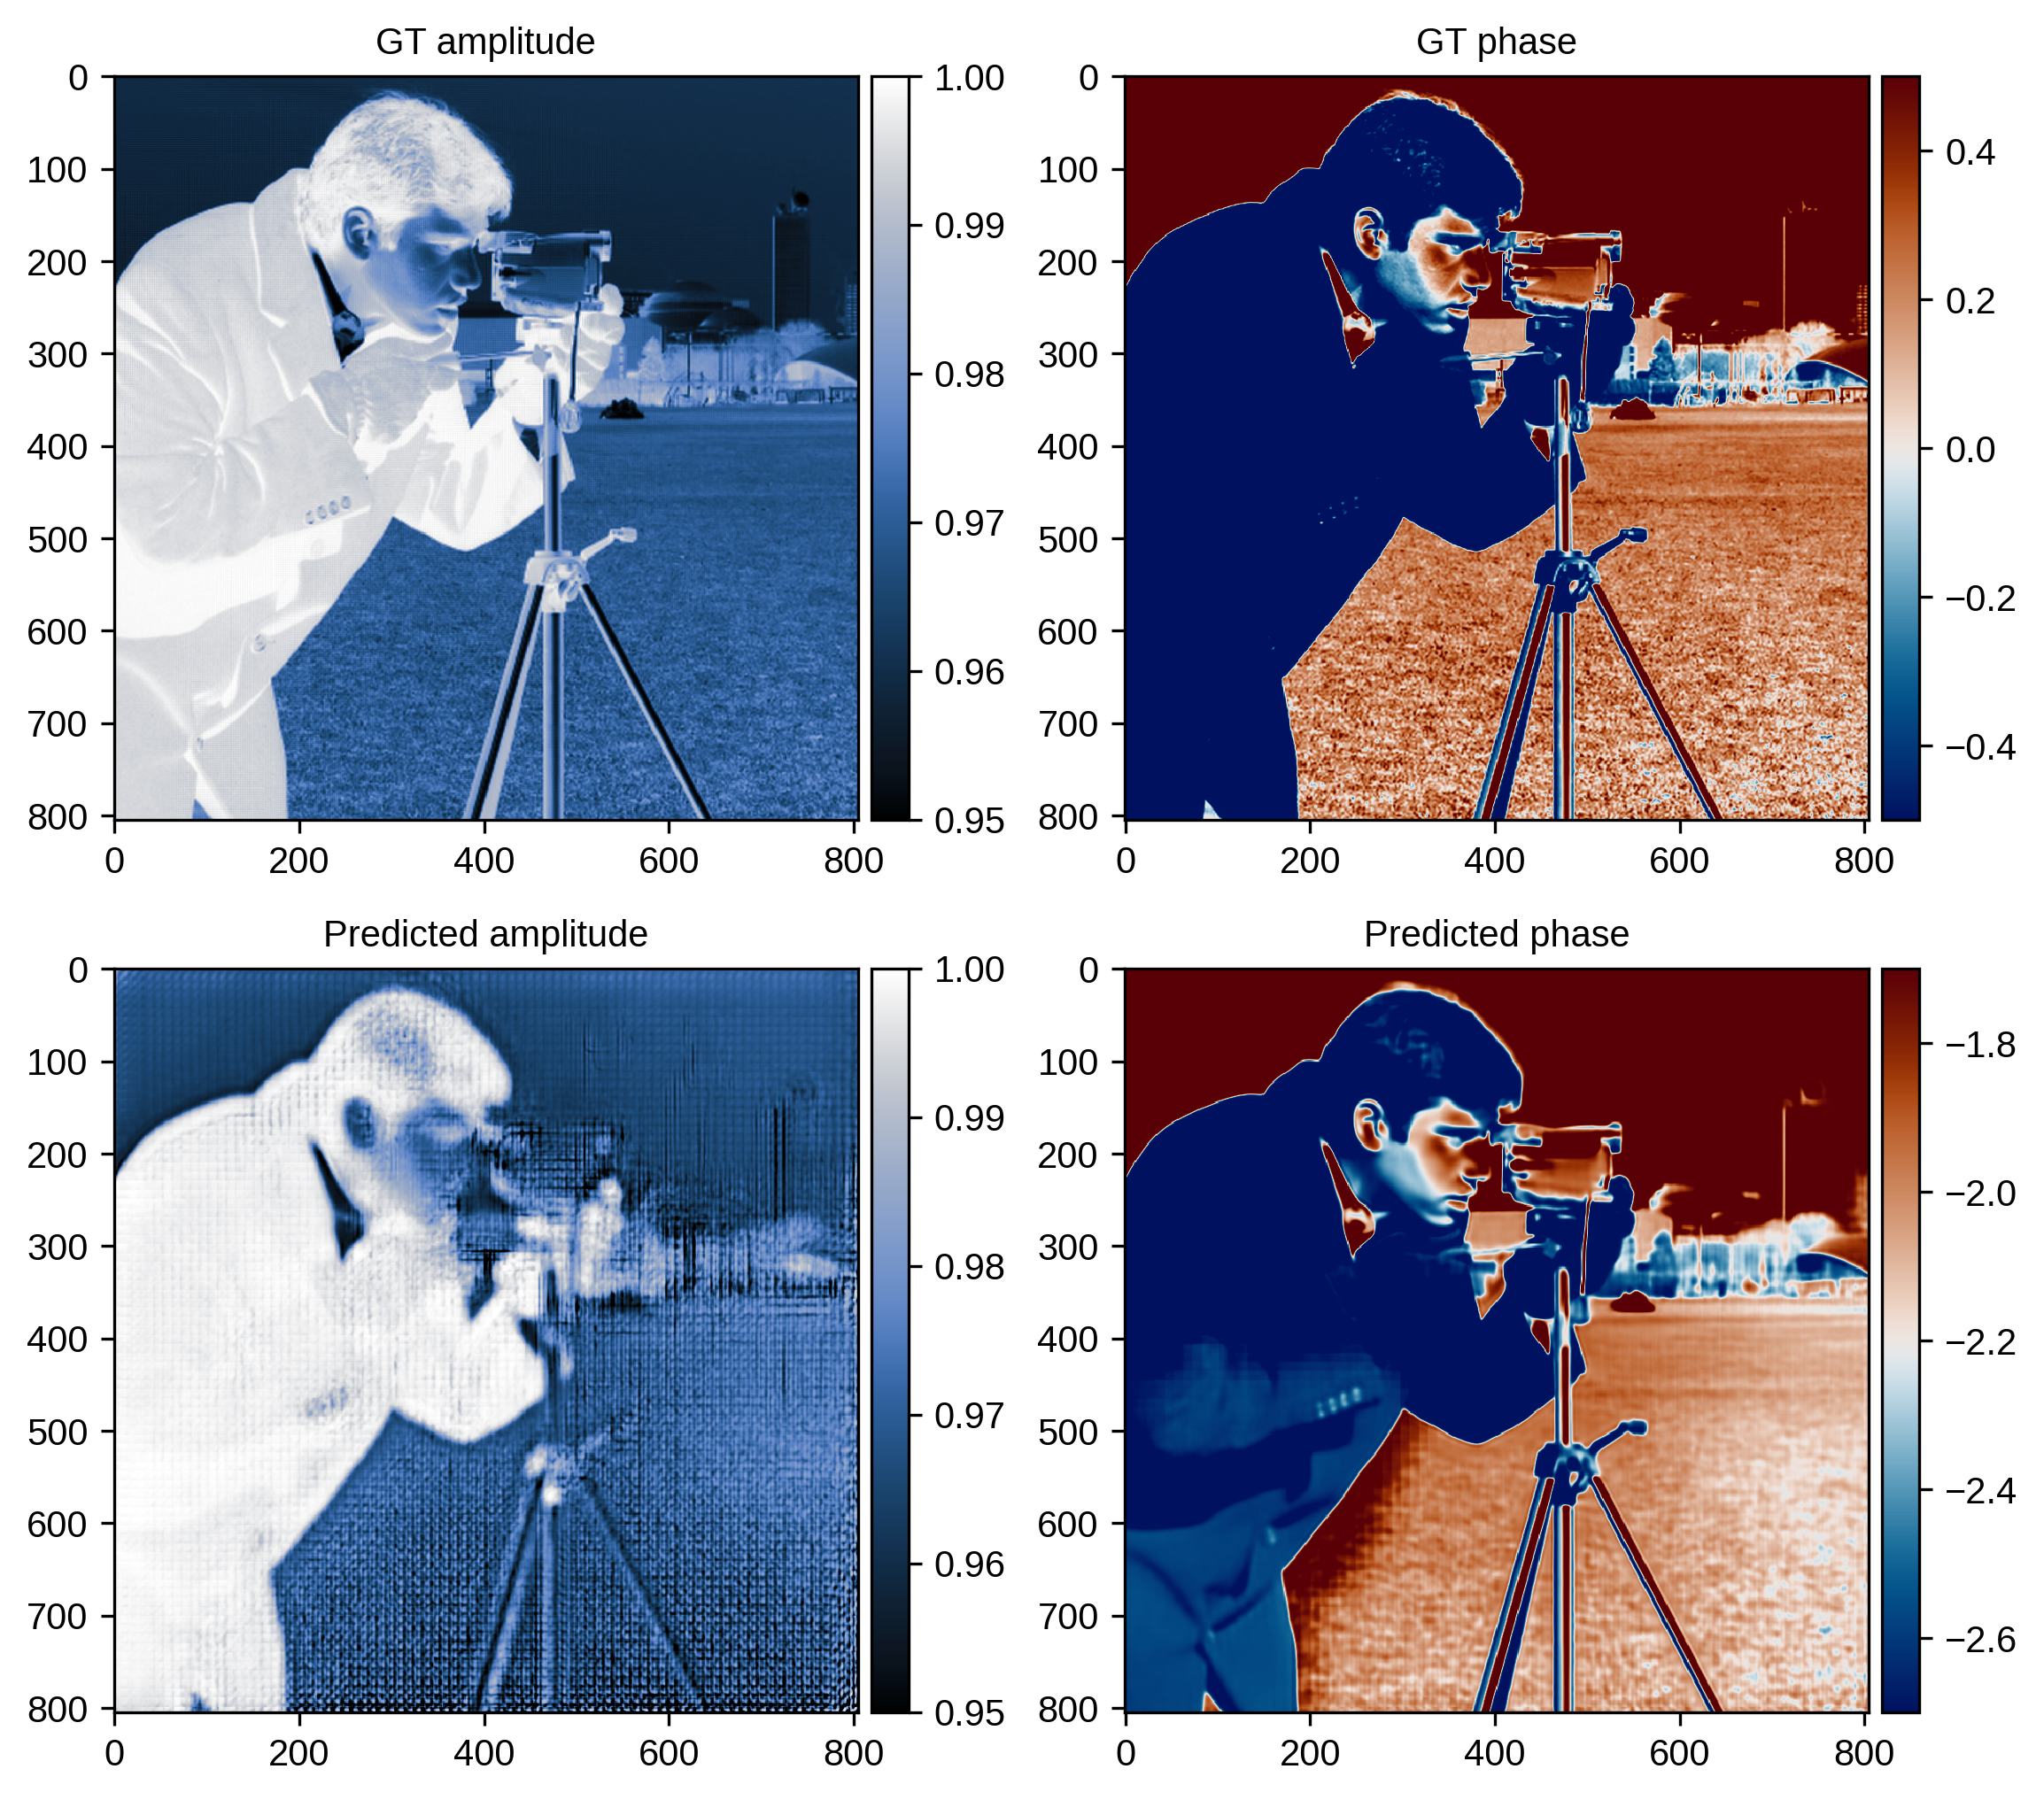

In [93]:
f, ax = plt.subplots(figsize=(9, 8), ncols=2, nrows=2)

gt0 = ax[0, 0].imshow(gt_amp_object[111:-132, 111:-132], interpolation='none', vmin=0.95, vmax=1, cmap=cmc.oslo)
divider = make_axes_locatable(ax[0, 0])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(gt0, cax=cax, orientation='vertical')
ax[0, 0].set_title('GT amplitude')

gt1 = ax[0, 1].imshow(gt_ph_object[111:-132, 111:-132], interpolation='none', vmin=-0.5, vmax=0.5, cmap=cmc.vik)
divider = make_axes_locatable(ax[0, 1])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(gt1, cax=cax, orientation='vertical')
ax[0, 1].set_title('GT phase')

pred0 = ax[1, 0].imshow(pred_amp_object[111:-132, 111:-132], interpolation='none', vmin=0.95, vmax=1, cmap=cmc.oslo)
divider = make_axes_locatable(ax[1, 0])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(pred0, cax=cax, orientation='vertical')
ax[1, 0].set_title('Predicted amplitude')

pred1 = ax[1, 1].imshow(pred_ph_object[111:-132, 111:-132], interpolation='none', vmin=-2.7, vmax=-1.7, cmap=cmc.vik)
divider = make_axes_locatable(ax[1, 1])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(pred1, cax=cax, orientation='vertical')
ax[1, 1].set_title('Predicted phase')

Text(0.5, 1.0, 'Predicted phase')

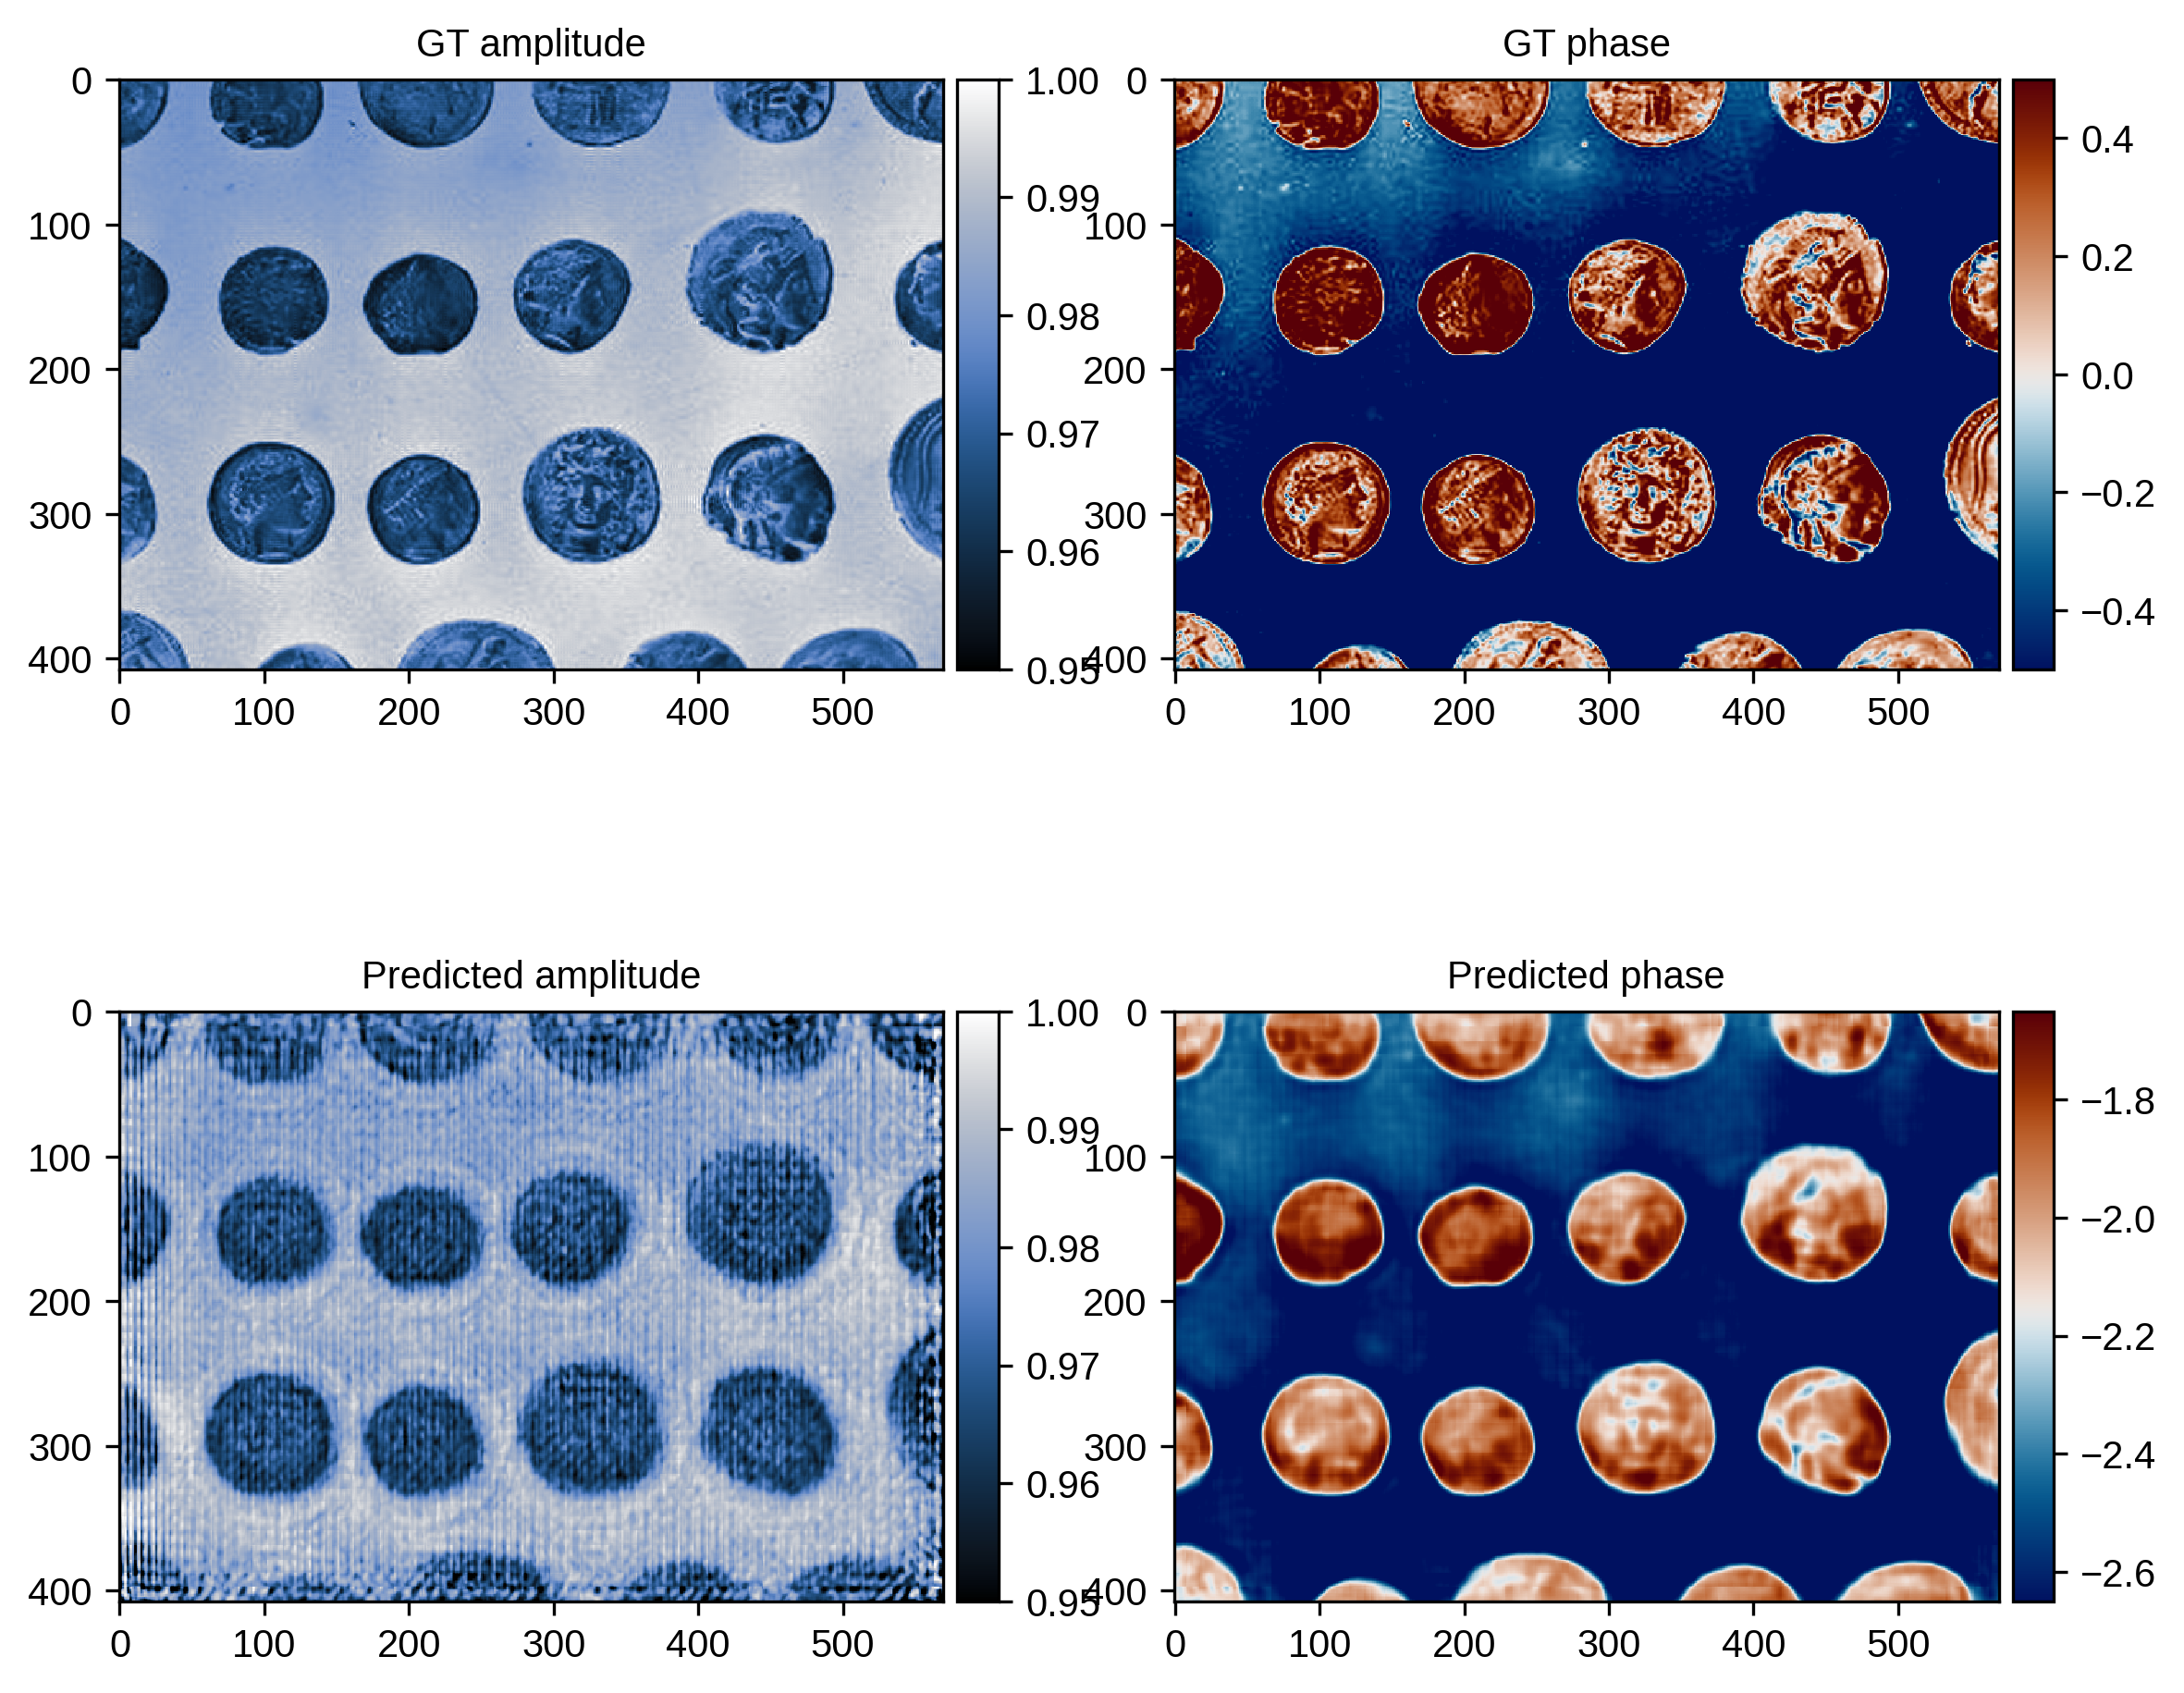

In [11]:
f, ax = plt.subplots(figsize=(9, 8), ncols=2, nrows=2)

gt0 = ax[0, 0].imshow(gt_amp_object[99:-99, 99:-99], interpolation='none', vmin=0.95, vmax=1, cmap=cmc.oslo)
divider = make_axes_locatable(ax[0, 0])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(gt0, cax=cax, orientation='vertical')
ax[0, 0].set_title('GT amplitude')

gt1 = ax[0, 1].imshow(gt_ph_object[99:-99, 99:-99], interpolation='none', vmin=-0.5, vmax=0.5, cmap=cmc.vik)
divider = make_axes_locatable(ax[0, 1])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(gt1, cax=cax, orientation='vertical')
ax[0, 1].set_title('GT phase')

pred0 = ax[1, 0].imshow(pred_amp_object[99:-99, 99:-99], interpolation='none', vmin=0.95, vmax=1, cmap=cmc.oslo)
divider = make_axes_locatable(ax[1, 0])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(pred0, cax=cax, orientation='vertical')
ax[1, 0].set_title('Predicted amplitude')

pred1 = ax[1, 1].imshow(pred_ph_object[99:-99, 99:-99], interpolation='none', vmin=-2.65, vmax=-1.65, cmap=cmc.vik)
divider = make_axes_locatable(ax[1, 1])
cax = divider.append_axes('right', size='5%', pad=0.05)
f.colorbar(pred1, cax=cax, orientation='vertical')
ax[1, 1].set_title('Predicted phase')

In [27]:
def gen_plot(gt_diff, gt_amp, gt_ph, pred_diff, pred_amp, pred_ph):
    f, ax = plt.subplots(figsize=(7, 4), nrows=2, ncols=3)

    in0 = ax[0, 0].imshow(gt_diff, interpolation='none', norm=colors.LogNorm(vmin=0.1, vmax=100), cmap=cmc.lapaz)
    divider = make_axes_locatable(ax[0, 0])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    f.colorbar(in0, cax=cax, orientation='vertical')
    ax[0, 0].set_title('Input Diff. Amp.')

    in1 = ax[0, 1].imshow(gt_amp, interpolation='none', vmin=0.95, vmax=1, cmap=cmc.oslo)
    divider = make_axes_locatable(ax[0, 1])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    f.colorbar(in1, cax=cax, orientation='vertical', format='%.2f')
    ax[0, 1].set_title('GT Amp.')

    in2 = ax[0, 2].imshow(gt_ph, interpolation='none', vmin=-0.5, vmax=0.5, cmap=cmc.vik)
    divider = make_axes_locatable(ax[0, 2])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    f.colorbar(in2, cax=cax, orientation='vertical', format='%.1f')
    ax[0, 2].set_title('GT Phase')

    out0 = ax[1, 0].imshow(pred_diff, interpolation='none', norm=colors.LogNorm(vmin=0.1, vmax=100), 
                           cmap=cmc.lapaz)
    divider = make_axes_locatable(ax[1, 0])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    f.colorbar(out0, cax=cax, orientation='vertical')
    ax[1, 0].set_title('Output Diff. Amp.')

    out1 = ax[1, 1].imshow(pred_amp, interpolation='none', cmap=cmc.oslo)
    divider = make_axes_locatable(ax[1, 1])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    f.colorbar(out1, cax=cax, orientation='vertical', format='%.2f')
    ax[1, 1].set_title('Predicted Amp.')

    out2 = ax[1, 2].imshow(pred_ph, interpolation='none', cmap=cmc.vik)
    divider = make_axes_locatable(ax[1, 2])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    f.colorbar(out2, cax=cax, orientation='vertical', format='%.1f')
    ax[1, 2].set_title('Predicted Phase')

    plt.tight_layout()
    return f, ax

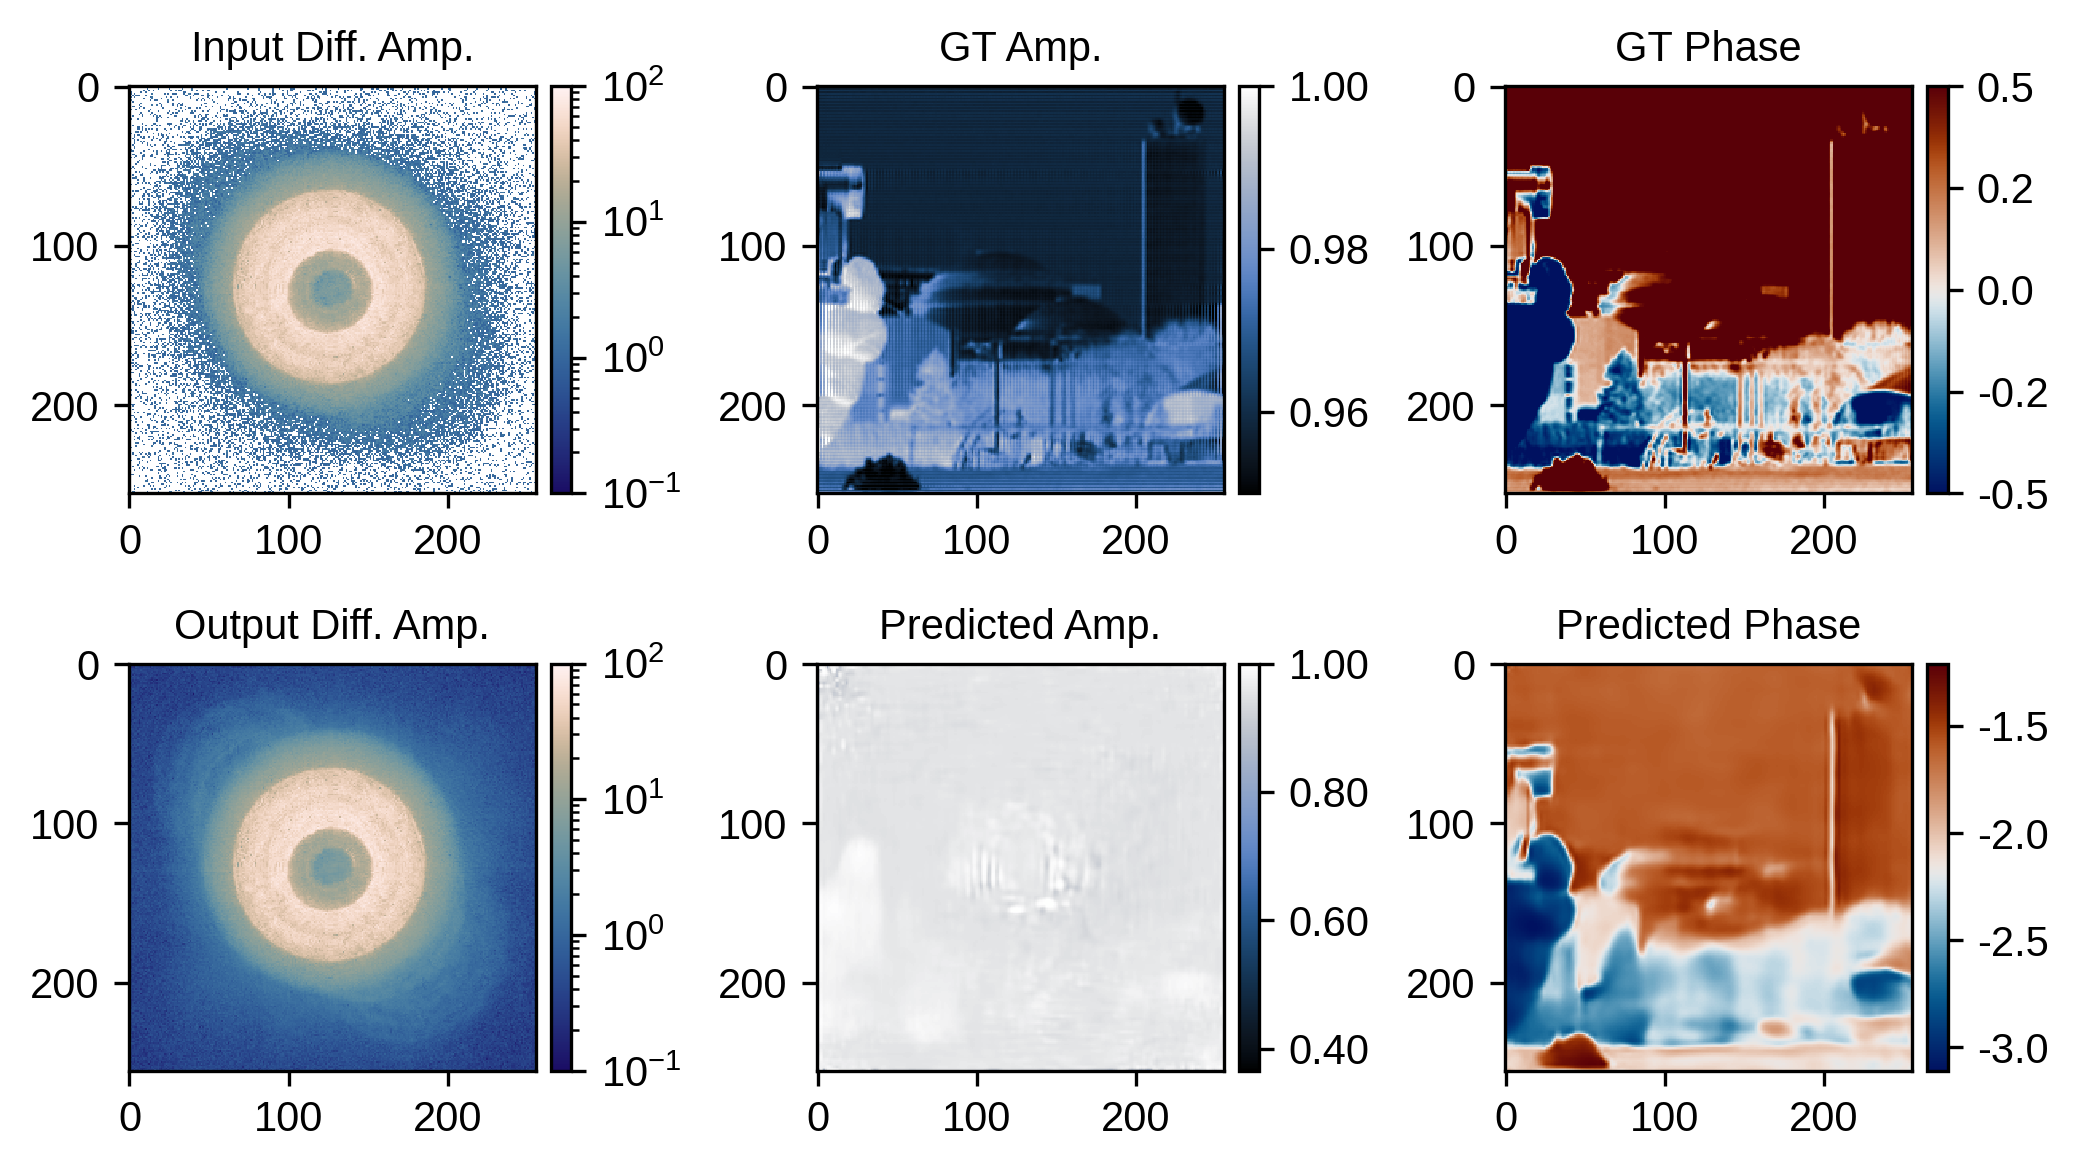

In [28]:
f, ax = gen_plot(gt_diff_test[5000], gt_amp_test[5000], gt_ph_test[5000], 
                 pred_diff_test[5000], pred_amp_test[5000], pred_ph_test[5000])